In [1]:
%pylab inline

import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
from scipy.spatial.distance import pdist
import scanpy as sc
import pandas as pd
import matplotlib
import pickle
import scipy
import time
import os
import warnings
from collections import namedtuple
warnings.filterwarnings('ignore')

sns.set_style('ticks')

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import neurom as nm
from neurom import viewer
from neurom.view import matplotlib_utils

In [3]:
# define data format
from collections import namedtuple
RNAseqData = namedtuple('RNAseqData', 'counts genes cells clusterIDs clusterLabels clustergroupIDs '
                                      'clusterColors clusterNames clustergroupNames cellnames mappingrates')

# create the color table for neuron clusters.
clusterColors_exc_table=np.array(['#98A14E', 
                              '#008000', '#2E8B57', '#96C390', '#6FBC1E', '#6D9269', 
                              '#90EE90', '#224700', '#228B22', '#00FF7F', '#ADD8E6',  #'#7CFC00',#  10
                              '#4666A6', '#1E90FF', '#B4BA77', '#1B655D', '#008B8B', 
                              '#00CED1', '#20B2AA', '#66CDAA', '#00FF00',])   ### greenish colors for excitatory neurons 
                              
clusterColors_inh_table = np.array(['#DDACC9', '#FF88AD', '#DD8091', '#F08E98', '#FF7290', '#FF8C97',
                              '#FFA388', '#C77963', '#7E0ACB', '#9440F3', '#9611B6', '#9900B3',
                              '#7A0099', '#AA4DB5', '#A720FF', '#AB1DFF', '#FF5FCD', '#FF4DC1',
                              '#B09FFF', '#BD3D9A', '#992E81', '#F70CF3', '#FF00FF', '#AB379C',
                              '#B3128A', '#7779BF', '#626EB8', '#FFFF00', '#FF8011', '#FF9F2C',
                              '#FFB307', '#FFBF09', '#BFAF00', '#FFB22B', '#D9C566', '#BE8652',      ### redish colors for inhibttory neurons.
                              ])

# Load the morphological data.

In [4]:
dataMorph = pd.read_excel('./dataMorph/morphFeatMatrix.xlsx',index_col=0)
dataMorph

,cellTypeID,cellType_expert,predictClusterID,allBasalDenLen,apicalLen,axonDist,axonLen,centroid_allBasalDenY,centroid_apicalY,centroid_axonY,...,totalApicalSurfaceArea,totalApicalVolume,totalAxonLength,totalAxonVolume,totalBasalLength,totalBasalSurfaceArea,totalBasalVolume,totalLen,totalSurfaceArea,totalVolume
B112,2,PC_L5',8,1573.569723,2471.737105,2.492281,679.656167,-40.073408,182.565365,-81.289321,...,6052.016898,1452.852726,679.656132,112.952230,1573.569670,3379.445353,627.588079,4724.962995,982.193300,2229.522436
B15,2,PC_L6',8,768.102720,2121.989931,0.919874,179.515596,-18.156018,215.944276,-75.341351,...,5374.481830,1153.040061,179.515594,92.504333,768.102694,1970.483373,435.120017,3069.608247,456.811553,1711.248169
B154,2,PC_L5',8,3573.866010,2851.954476,0.000000,189.843234,-65.531695,129.438833,-72.495039,...,17160.585810,8388.612917,189.837616,279.842268,3573.845681,20466.481440,9415.182072,6615.663719,817.057703,18318.863780
B333,3,PC_L5',16,1175.873685,4985.431714,0.000000,384.231236,-52.228937,694.344366,-116.328630,...,12409.301220,3354.256245,384.231206,74.011240,1175.873682,2576.612835,476.754165,6545.536635,594.383001,3950.097941
B361,3,PC_L5',16,2125.014867,5476.910860,0.000000,656.113741,-44.892461,902.188002,-219.729792,...,15095.723730,4397.648419,656.113703,170.800233,2125.014842,5107.076002,1053.779169,8258.039468,1184.810304,5667.386150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s722,1,PC_L5',18,1390.448694,1203.991459,0.000000,121.033303,-80.376683,127.456794,-57.690645,...,3873.260493,1082.225143,121.033295,45.257749,1390.448693,3692.432813,884.374916,2715.473456,262.363755,2050.223439
s725,1,PC_L5',18,2161.712022,2429.440311,0.000000,66.087886,-67.492119,367.272940,-32.398086,...,7054.724031,2316.335561,66.087875,48.232372,2161.712045,4739.931023,874.023682,4657.240219,189.744714,3257.442440
s727,1,PC_L5',6,3309.298558,4598.691892,0.000000,112.109683,-74.294985,308.267710,-50.322418,...,13177.754160,4578.785066,112.109673,88.453375,3309.298612,6698.096619,1170.862221,8020.100133,347.307096,7778.147988
s732,1,',6,4575.900822,2557.163073,NaN,NaN,8.578133,199.092911,NaN,...,5981.974922,1461.848069,0.000000,0.000000,4575.900916,8849.595514,1460.721038,NaN,0.000000,2951.127988


In [5]:
cellTypeID = dataMorph['cellTypeID']
# dataMorph = dataMorph.drop('cellTypeID',axis=1)

In [6]:
morphFeatIncude = ['allBasalDenLen', 'apicalLen', 
       'centroid_allBasalDenY', 'centroid_apicalY', 'height',
       'lengthFractionAboveSoma_apical', 'lengthFractionAboveSoma_basal', 'maxApicalY', 'maxBasalRadius',
       'maxBranchHeight', 'maxBranchHeight_percent', 'maxOrder_apical',
       'maxOrder_basal', 'maxRadialDist_apical',
       'maxRadialDist_basal', 'minBasalY',
       'nApicalBranch', 'nBasalBranch', 'nTopForks',
       'numNeurite', 'numNeurite_basal', 'numSec_apical',
       'numSec_basal', 'shapeFactor_apical',
       'shapeFactor_basal', 'somaArea', 'somaDepth', 'somaDepth_norm',
       'somaRatio1', 'somaRatio2', 'somaSize', 'soma_radius', 'surfArea',
       'thickRatio', 'topForkPercent', 'topApicalLen', 'totalApicalLength',
       'totalApicalSurfaceArea', 'totalApicalVolume',
       'totalBasalLength', 'totalBasalSurfaceArea',
       'totalBasalVolume', 'totalLen', 'totalSurfaceArea', 'totalVolume']

In [7]:
dataMorph_t = dataMorph.copy()
dataMorph = dataMorph[morphFeatIncude]
dataMorph

,allBasalDenLen,apicalLen,centroid_allBasalDenY,centroid_apicalY,height,lengthFractionAboveSoma_apical,lengthFractionAboveSoma_basal,maxApicalY,maxBasalRadius,maxBranchHeight,...,topApicalLen,totalApicalLength,totalApicalSurfaceArea,totalApicalVolume,totalBasalLength,totalBasalSurfaceArea,totalBasalVolume,totalLen,totalSurfaceArea,totalVolume
B112,1573.569723,2471.737105,-40.073408,182.565365,784.30,0.954818,0.193959,636.16,1.73,136.40,...,190.0,2471.737098,6052.016898,1452.852726,1573.569670,3379.445353,627.588079,4724.962995,982.193300,2229.522436
B15,768.102720,2121.989931,-18.156018,215.944276,683.30,1.000000,0.389749,599.28,1.96,193.83,...,212.0,2121.989897,5374.481830,1153.040061,768.102694,1970.483373,435.120017,3069.608247,456.811553,1711.248169
B154,3573.866010,2851.954476,-65.531695,129.438833,48.57,1.000000,0.034394,-9.90,3.09,-22.65,...,0.0,2852.186510,17160.585810,8388.612917,3573.845681,20466.481440,9415.182072,6615.663719,817.057703,18318.863780
B333,1175.873685,4985.431714,-52.228937,694.344366,1451.33,0.986380,0.065466,1257.27,2.42,405.48,...,1383.0,4985.432042,12409.301220,3354.256245,1175.873682,2576.612835,476.754165,6545.536635,594.383001,3950.097941
B361,2125.014867,5476.910860,-44.892461,902.188002,1750.53,0.986707,0.236285,1497.76,2.29,629.85,...,2448.0,5476.910683,15095.723730,4397.648419,2125.014842,5107.076002,1053.779169,8258.039468,1184.810304,5667.386150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s722,1390.448694,1203.991459,-80.376683,127.456794,681.25,0.992922,0.000000,384.51,2.75,78.38,...,236.0,1203.991467,3873.260493,1082.225143,1390.448693,3692.432813,884.374916,2715.473456,262.363755,2050.223439
s725,2161.712022,2429.440311,-67.492119,367.272940,1243.40,1.000000,0.052071,943.34,1.72,244.54,...,530.0,2429.440182,7054.724031,2316.335561,2161.712045,4739.931023,874.023682,4657.240219,189.744714,3257.442440
s727,3309.298558,4598.691892,-74.294985,308.267710,1253.20,0.950877,0.040247,972.08,2.76,507.47,...,584.0,4598.020544,13177.754160,4578.785066,3309.298612,6698.096619,1170.862221,8020.100133,347.307096,7778.147988
s732,4575.900822,2557.163073,8.578133,199.092911,656.86,1.000000,0.502428,461.46,2.64,345.30,...,375.0,2557.163164,5981.974922,1461.848069,4575.900916,8849.595514,1460.721038,NaN,0.000000,2951.127988


# Load the patchseq data and mapping results (cluster IDs)

In [8]:
# loading patched cell data
patchSeqData=pickle.load(open('../patchSeqMappingTo10X//data/processedData/insPatchDataNew251010.pickle', 'rb')) 
# patchSeqData=pickle.load(open('./data/processedData/insPatchData.pickle', 'rb')) 
counts_patchSeq = patchSeqData.counts
genes_patchSeq = patchSeqData.genes.astype('str')
patchCellNames = patchSeqData.cellnames
patchCellTypeIDs = patchSeqData.clustergroupIDs
patchCellTypes = patchSeqData.clustergroupNames
patchCellSubtypeIDs= patchSeqData.clusterIDs
patchCellSubtypes= patchSeqData.clusterNames
mappingRates= patchSeqData.mappingrates

In [9]:
# load the predicted cluster IDs of patchSeq cells.
predictClusterIDs = pd.read_csv('../patchSeqMappingTo10X/data/mappingRes/results_Ext_240415.csv',index_col=0)

# Load the excitatory neurons (10X)

In [10]:
# load the umap mapping positions of patch-seq cells
mappingUmap_Ext = pd.read_csv('../patchSeqMappingTo10X//data/mappingRes/df_pos_umap_Ext_240415.csv', index_col=0)
# load the scanpy data of Ext neurons.
ad_Ext = sc.read('../10X/data_h5/Ext.h5ad')
ad_Ext

AnnData object with n_obs × n_vars = 21733 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cluster_labels', 'sampleLayers', 'projectionCellType', 'Sex'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sex_colors', 'batch_colors', 'cluster_labels_colors', 'cluster_names', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'projectionCellType_colors', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', 'X_umapraw'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

In [11]:
# load the hgh variable genes of 10X clusters.
tem = pd.read_csv('../patchSeqMappingTo10X/data/mappingRes/HVG_10XExt.csv',index_col=0)
HVG_ext = list(tem['0'])

gg = sorted(list(set(genes_patchSeq) & set(HVG_ext)))
idx_HVG_new = [np.where(genes_patchSeq==g)[0][0] for g in gg]
HVG_new = genes_patchSeq[idx_HVG_new]
counts_patchSeq = counts_patchSeq[:, idx_HVG_new]        ### IMPORTANT: If first time ran the routine, this line need to be un-commented.

In [12]:
# get the umap positions of 10X data.
Z0_umap = ad_Ext.obsm['X_umap']
# assign the colors to Ext neuron subtypes.
clusterColors_Ext = clusterColors_exc_table[ad_Ext.obs['leiden'].astype('int')]

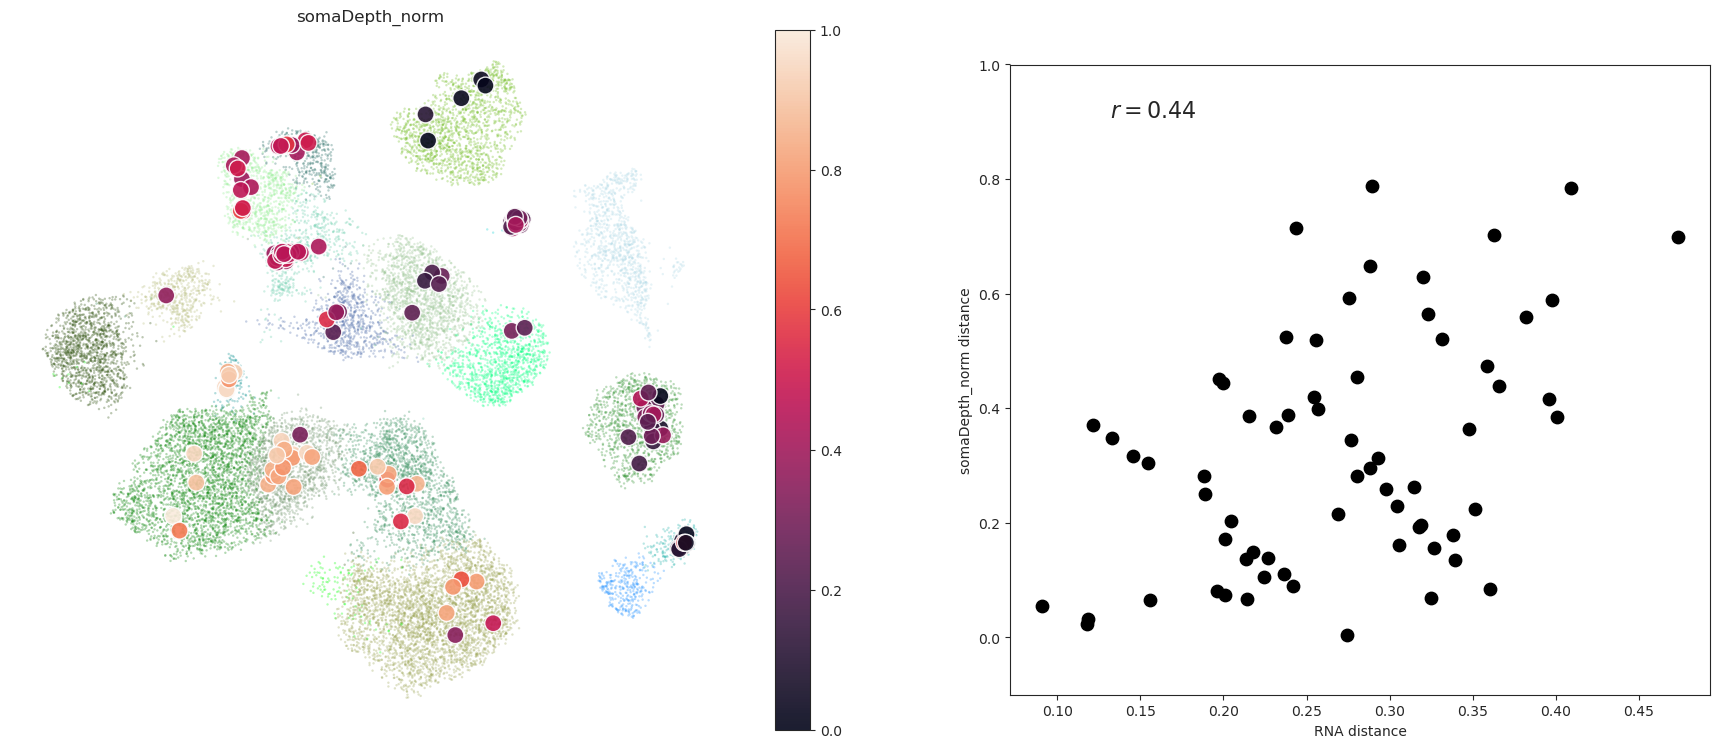

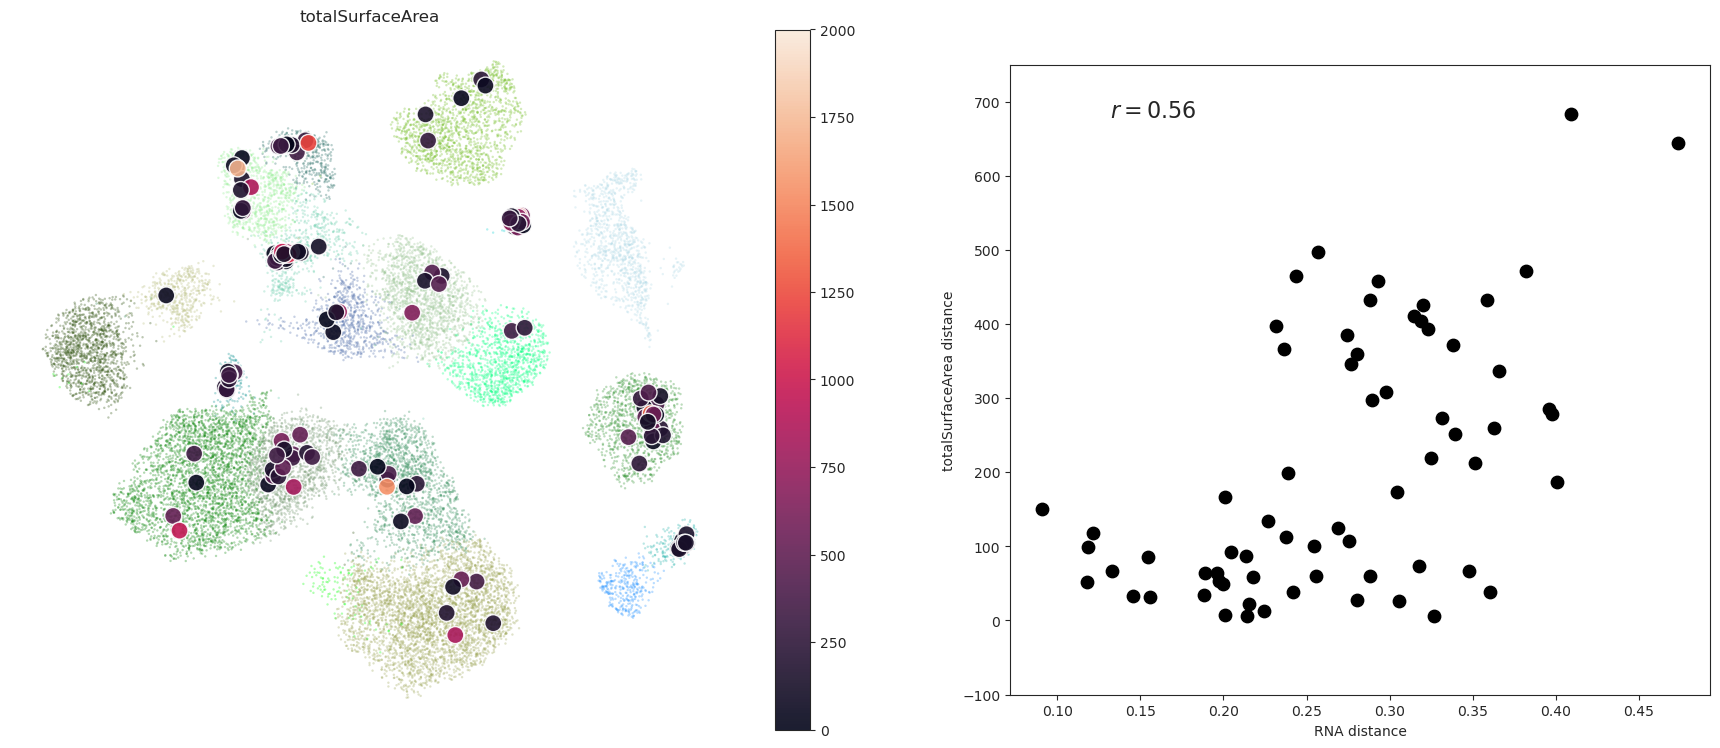

In [13]:
dotsize = 150

exampleFeat = ['somaDepth_norm','totalSurfaceArea']#'shapeFactor_apical']
for i, feat in enumerate(exampleFeat):
    # get the morph feature values.
    featValues = dataMorph[feat]
    goodCell_ind = intersect1d(mappingUmap_Ext.index.astype('str'),featValues.index)
    featValues_good = featValues.loc[ goodCell_ind]
    mappingUmap_Ext_good=mappingUmap_Ext.loc[ goodCell_ind,:]

    # jitter for the overlapped dots (dots mapping to the cluster FEZF2 DSG2) 
    overlapDots = (mappingUmap_Ext['UMAP1']>8.5) & (mappingUmap_Ext['UMAP1']<8.8) & (mappingUmap_Ext['UMAP2']>14) & (mappingUmap_Ext['UMAP2']<15)
    mappingUmap_overlapped = mappingUmap_Ext_good.loc[overlapDots,:]
    mappingUmap_nonOverlapped = mappingUmap_Ext_good.loc[~overlapDots,:]
    n_overlapDots = mappingUmap_overlapped.shape[0]
    
    # plot the mapping figures.
    fig = plt.figure(figsize=(20,7))
    ax1 = plt.axes([0.05,0,9/20,1])
    # plot 10X data
    plt.sca(ax1)
    plt.scatter(Z0_umap[:,0], Z0_umap[:,1], s=3, alpha=0.3,
                c = clusterColors_Ext, edgecolor='none',
                rasterized=True )
    # plot the cells with good ephy feature values.
    if feat =='somaDepth_norm':
        plt.scatter(mappingUmap_nonOverlapped['UMAP1'], mappingUmap_nonOverlapped['UMAP2'], s=dotsize, alpha=0.9,
                    c = 1-np.array(featValues_good[~overlapDots]), edgecolor='w', rasterized=True)
        plt.scatter(mappingUmap_overlapped['UMAP1']+0.7*np.random.rand(n_overlapDots), mappingUmap_overlapped['UMAP2']+0.7*np.random.rand(n_overlapDots), s=dotsize, alpha=0.9,
                    c = 1-np.array(featValues_good[overlapDots]), edgecolor='w', rasterized=True)
    else:
        plt.scatter(mappingUmap_nonOverlapped['UMAP1'], mappingUmap_nonOverlapped['UMAP2'], s=dotsize, alpha=0.9,
                    c = np.array(featValues_good[~overlapDots]), edgecolor='w', rasterized=True)
        plt.scatter(mappingUmap_overlapped['UMAP1']+0.8*np.random.rand(n_overlapDots), mappingUmap_overlapped['UMAP2']+0.8*np.random.rand(n_overlapDots), s=dotsize, alpha=0.9,
                    c = np.array(featValues_good[overlapDots]), edgecolor='w', rasterized=True)
        
    cbar = colorbar()

    # set figure properties
    if feat =='somaDepth_norm':
        plt.clim(0,1)
    else:
        plt.clim(0,2000)
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.title(feat)



    ax2 = plt.axes([11/20,0.05, 7/20,0.9])

    gg = sorted(list(set(genes_patchSeq) & set(HVG_ext)))
    idx_HVG_new = [np.where(genes_patchSeq==g)[0][0] for g in gg]
    HVG_new = genes_patchSeq[idx_HVG_new]
    # counts_patchSeq = counts_patchSeq[:, idx_HVG_new]        ### IMPORTANT: If first time ran the routine, this line need to be un-commented.

    featureMerged = pd.concat([featValues_good,predictClusterIDs],axis=1,join='inner',ignore_index=False)
    # featureMerged
    patchDataMtx = pd.DataFrame(counts_patchSeq,index=patchCellNames,columns=HVG_new)
    patchDataMtxMerged = pd.concat([featureMerged,patchDataMtx],axis=1,join='inner',ignore_index=False)

    clusters = np.array([  0, 1,  2, 4, 5, 6, 8, 14, 15, 16, 17, 18 ]) # only includes the cluster with >5 neurons mapped.
    meanFeatValues = np.ones(len(clusters))*np.nan
    meanCounts = np.ones([len(clusters), len(HVG_new)])*np.nan

    for j, cluster in enumerate(clusters):
        meanFeatValues[j] = np.mean(featureMerged.loc[featureMerged['predictClustersIDs']==cluster,feat])
        # meanCounts[j] = np.mean( np.log1p(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':]),axis=0 )  #'ACSL3'
        meanCounts[j] = np.log1p( np.mean(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':],axis=0) )

    Dist_ephyFeat = pdist(meanFeatValues[:,np.newaxis])
    Dist_counts = pdist(meanCounts,metric='correlation')
    # remove the NaNs.
    Dist_ephyFeat = Dist_ephyFeat[~isnan(Dist_ephyFeat)]
    Dist_counts = Dist_counts[~isnan(Dist_ephyFeat)]

    figsize(7,5)
    # plt.axes([1,0,2/5,1])
    plt.scatter(Dist_counts,Dist_ephyFeat,color='k',s=80)
    # plt.xlim([0,0.5])
    if feat=='somaDepth_norm':
        plt.ylim([-0.1,1])
    else:
        plt.ylim([-100,750])
    plt.xlabel('RNA distance')
    plt.ylabel( feat + ' distance')

    corrco=corrcoef(Dist_counts,Dist_ephyFeat)
    fig.text(12/20, .9, '$r={:.2f}$'.format(corrco[1,0]), fontsize=16, va='top')

    saveName = './figures/eachFeatDistCorr/'+feat+'--.pdf'
    # plt.savefig(saveName,dpi=600)

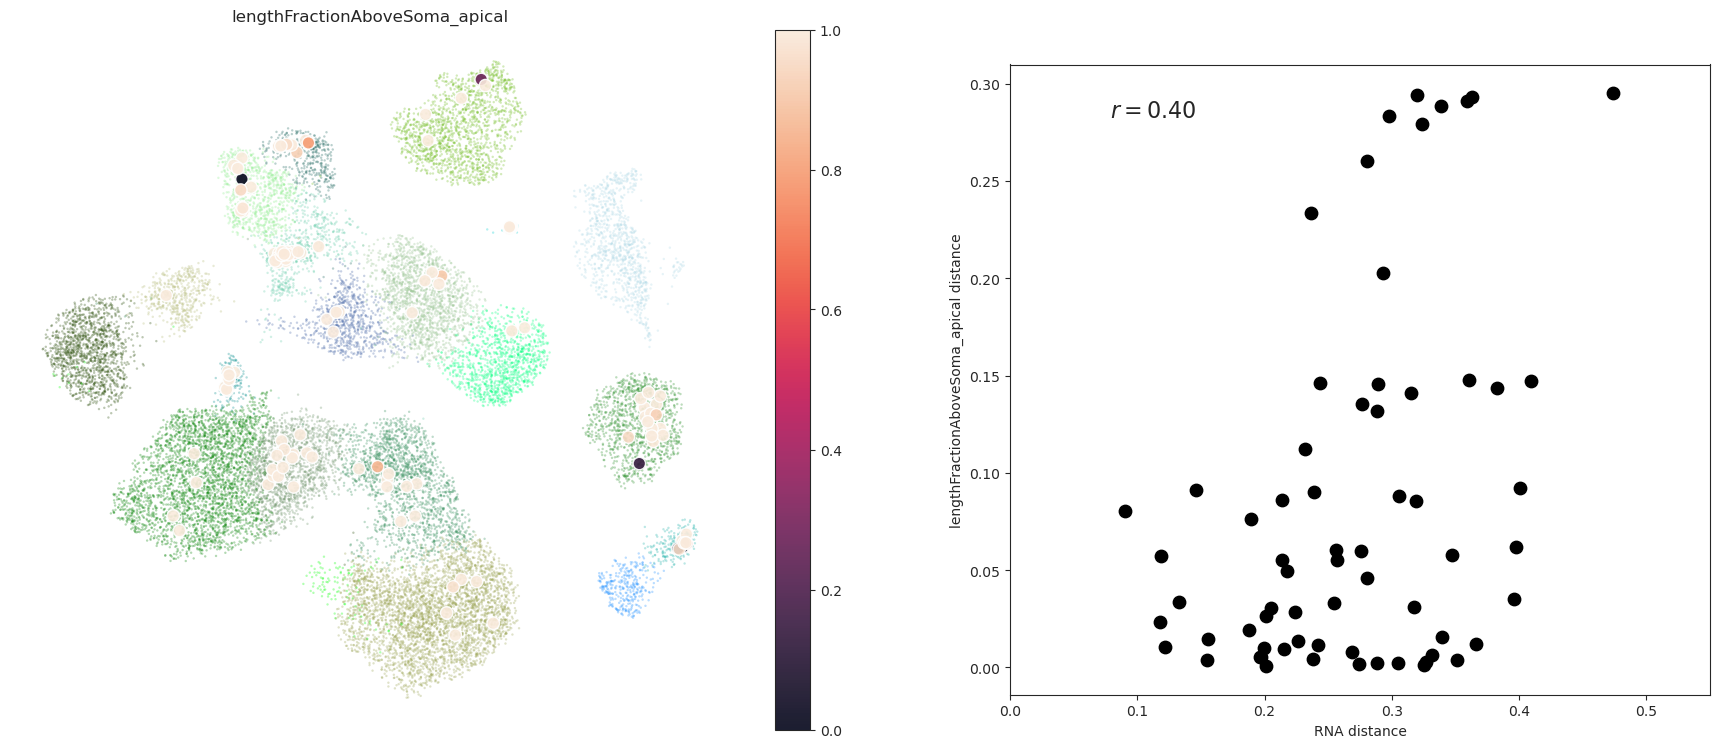

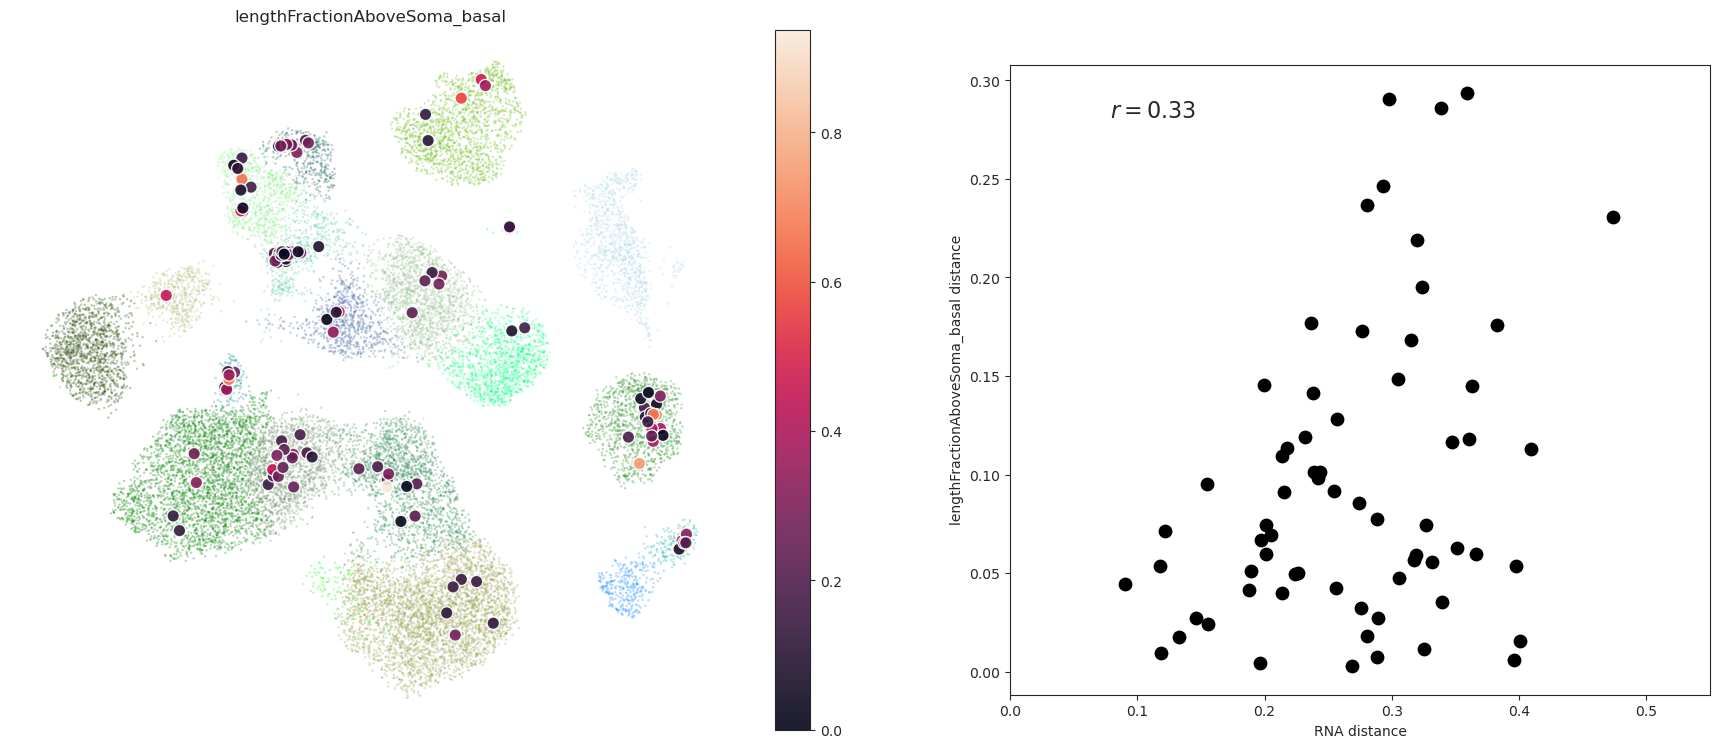

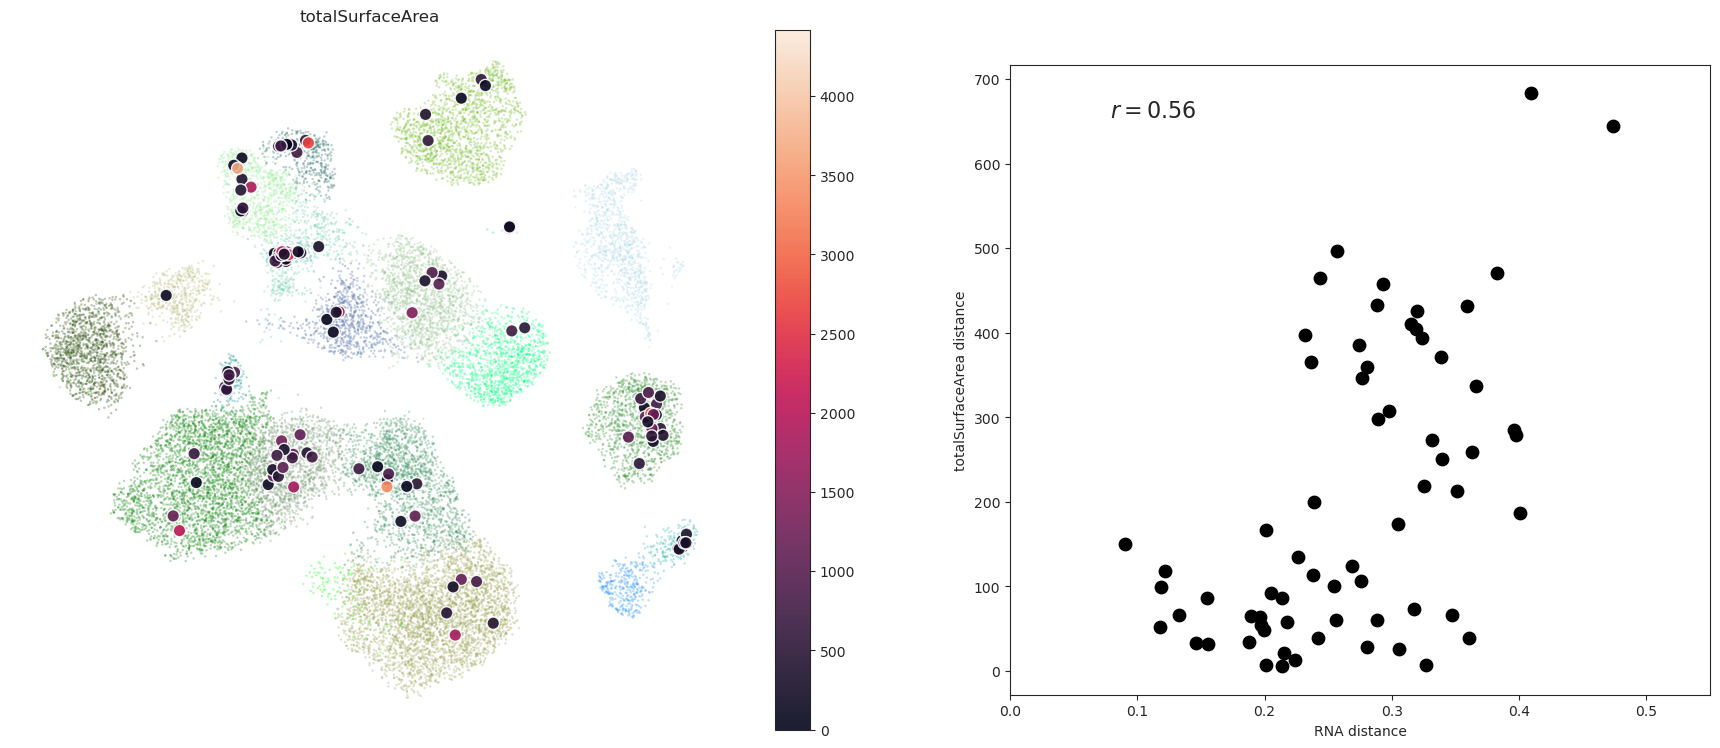

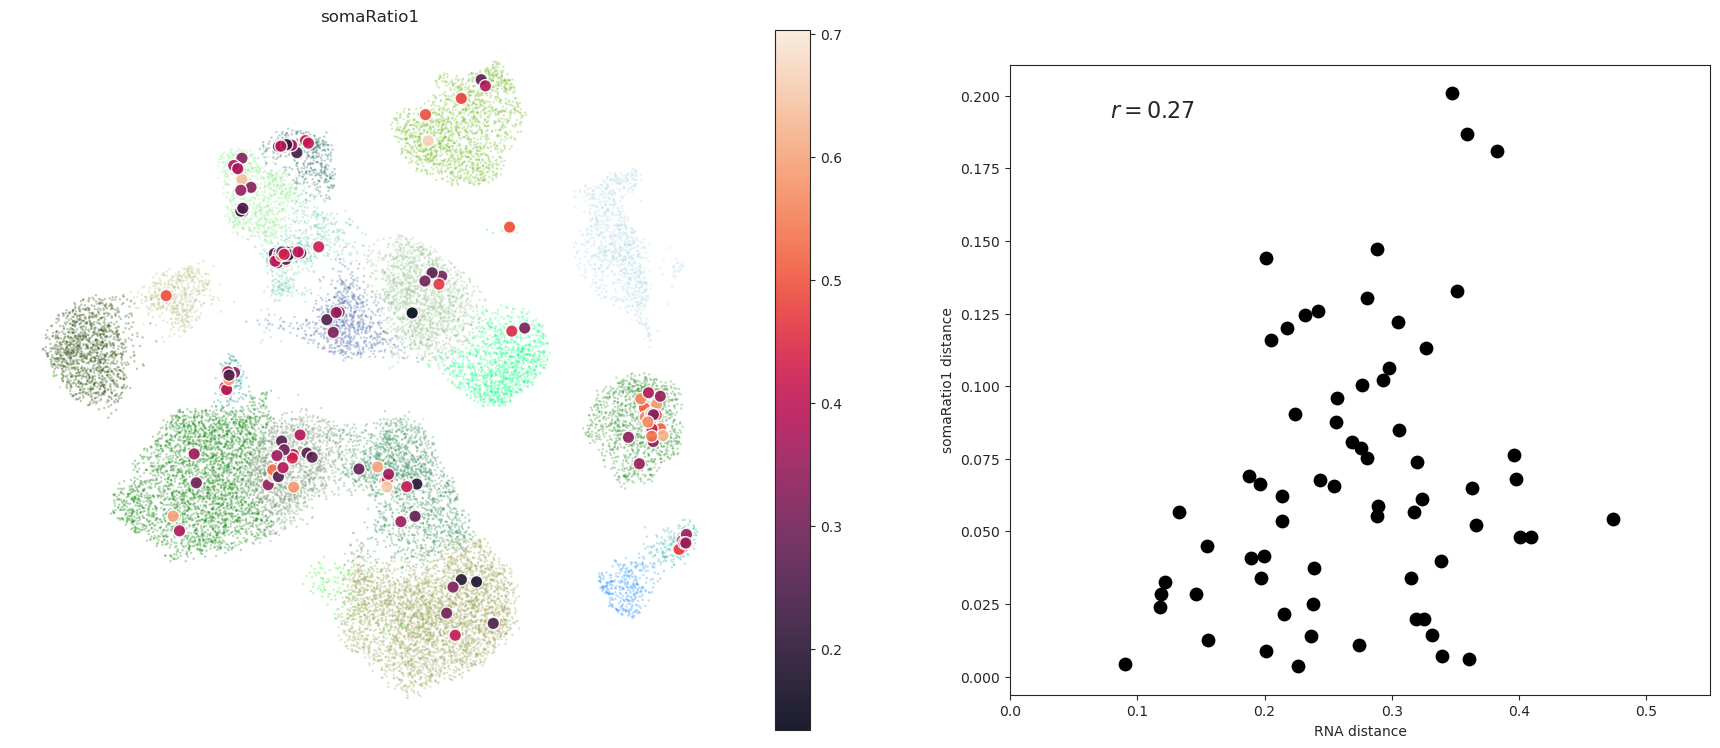

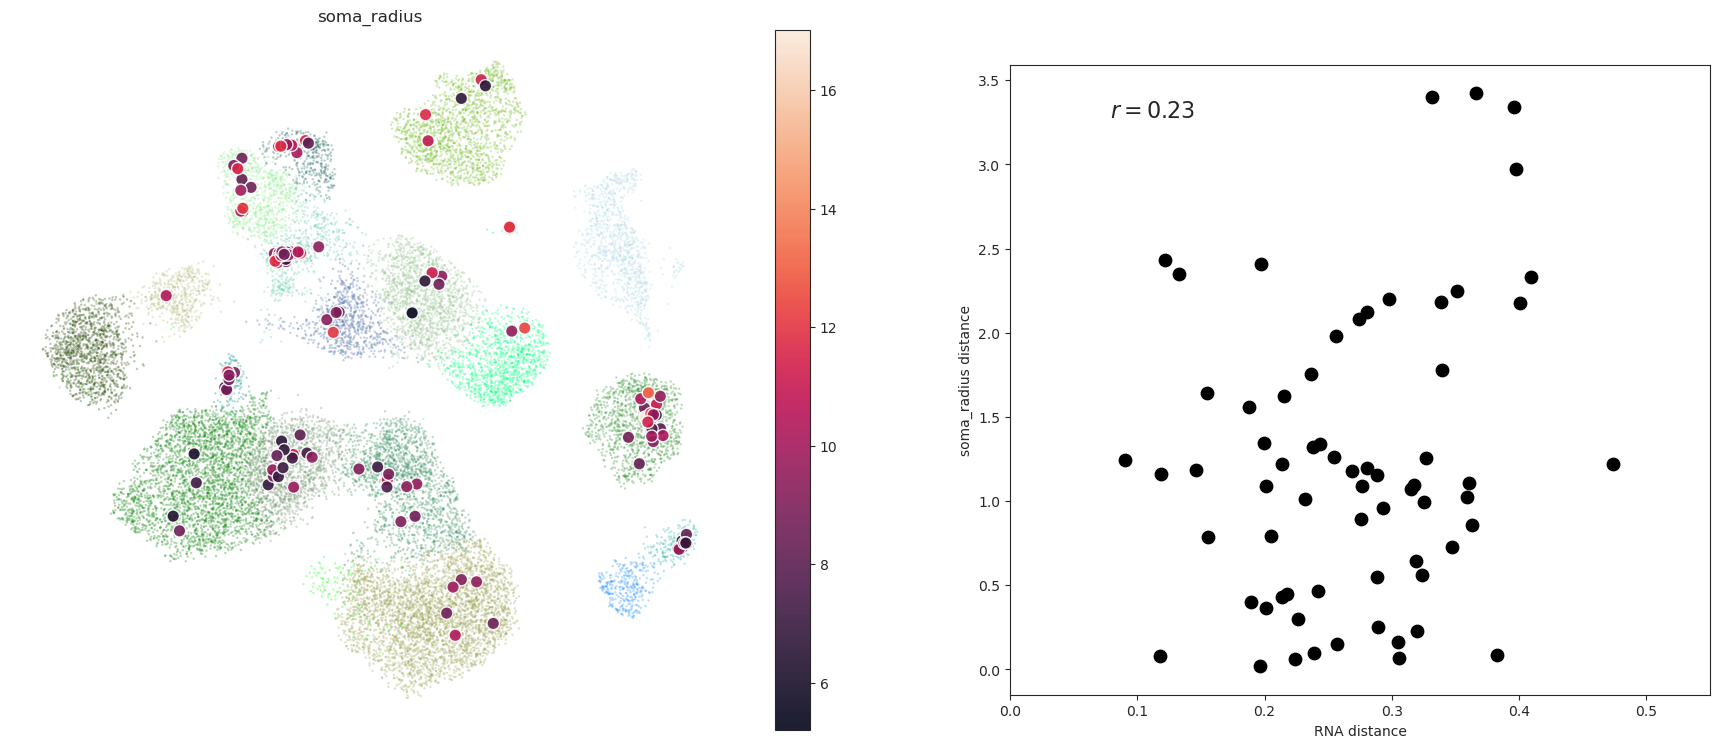

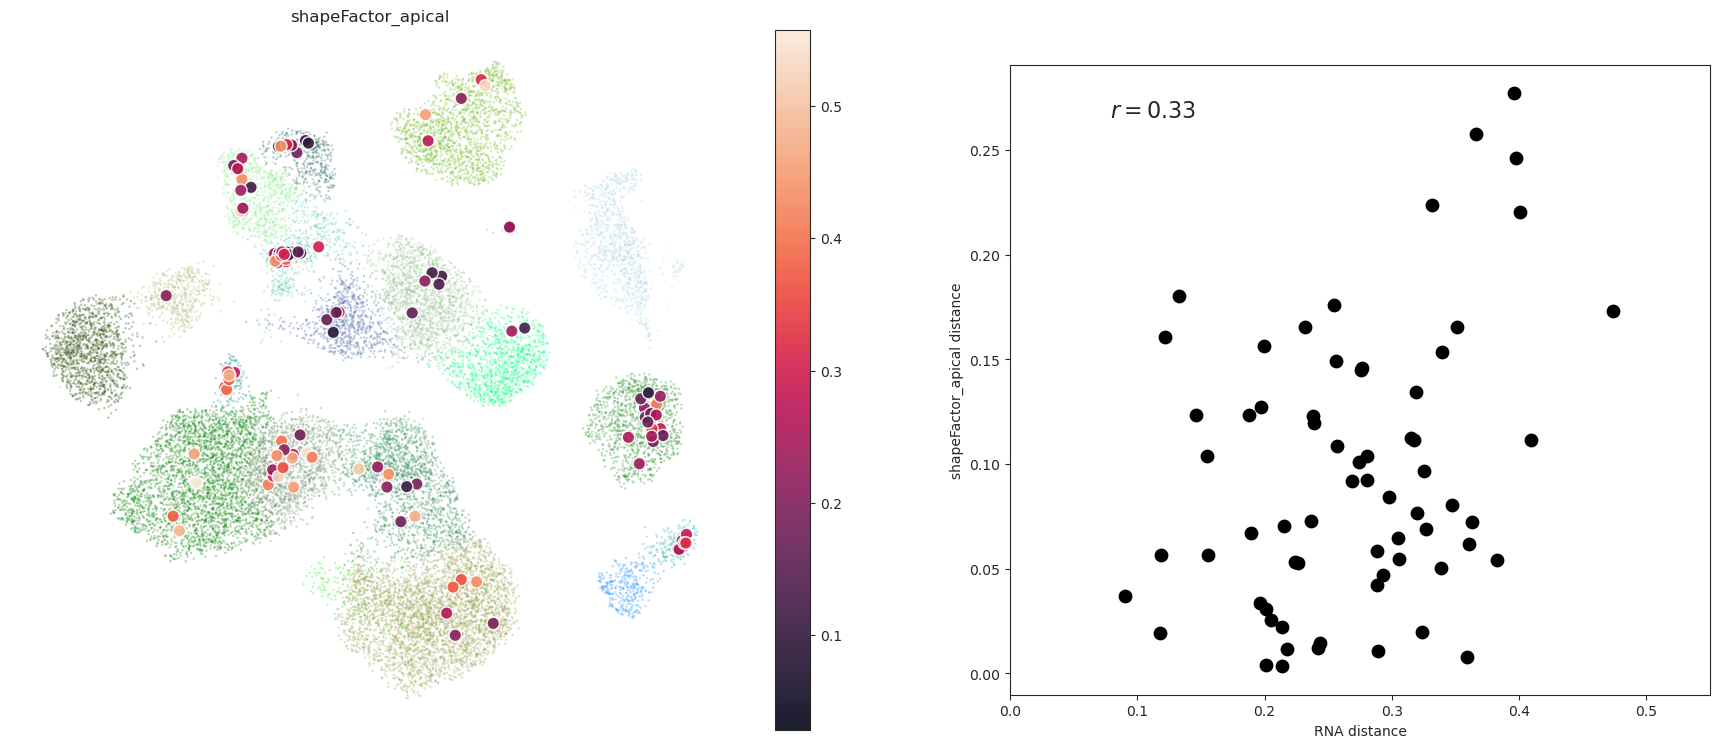

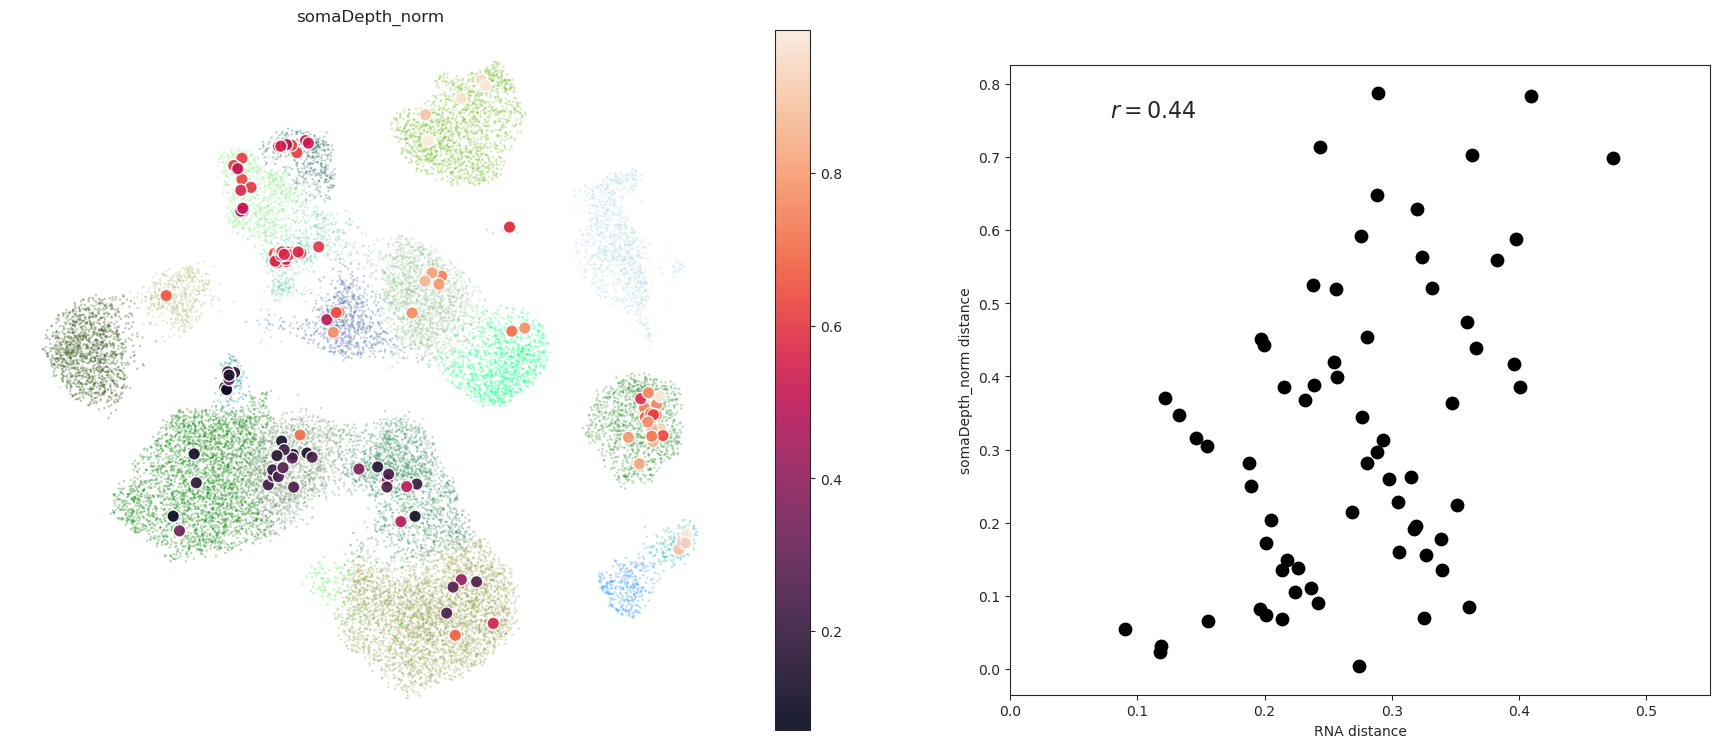

In [15]:
# plot all ehy features mapping 2 10X RNAseq data.

morphFeatureNames = dataMorph.columns
highCorrFeatures = ['lengthFractionAboveSoma_apical','lengthFractionAboveSoma_basal','totalSurfaceArea','somaRatio1','soma_radius','shapeFactor_apical','somaDepth_norm']

for i, feat in enumerate(highCorrFeatures):

    # get the morph feature values.
    featValues = dataMorph[feat]
    goodCell_ind = intersect1d(featValues.index,mappingUmap_Ext.index)
    featValues_good = featValues.loc[ goodCell_ind]
    mappingUmap_Ext_good=mappingUmap_Ext.loc[ goodCell_ind,:]

    # plot the mapping figures.
    fig = plt.figure(figsize=(20,7))
    ax1 = plt.axes([0.05,0,9/20,1])
    # plot 10X data
    plt.sca(ax1)
    plt.scatter(Z0_umap[:,0], Z0_umap[:,1], s=3, alpha=0.3,
                c = clusterColors_Ext, edgecolor='none',
                rasterized=True )
    # plot the cells with good ephy feature values.
    plt.scatter(mappingUmap_Ext_good['UMAP1'], mappingUmap_Ext_good['UMAP2'], s=80, alpha=0.9,
                c = np.array(featValues_good), edgecolor='w', rasterized=True)
    colorbar()
    # set figure properties
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.title(feat)



    ax2 = plt.axes([11/20,0.05, 7/20,0.9])

    featureMerged = pd.concat([featValues_good,predictClusterIDs],axis=1,join='inner',ignore_index=False)
    # featureMerged
    patchDataMtx = pd.DataFrame(counts_patchSeq,index=patchCellNames,columns=HVG_new)
    patchDataMtxMerged = pd.concat([featureMerged,patchDataMtx],axis=1,join='inner',ignore_index=False)

    clusters = np.array([ 0, 1,  2, 4, 5, 6, 8, 14, 15, 16, 17, 18 ]) # only includes the cluster with >5 neurons mapped.
    meanFeatValues = np.ones(len(clusters))*np.nan
    meanCounts = np.ones([len(clusters), len(HVG_new)])*np.nan

    for j, cluster in enumerate(clusters):
        meanFeatValues[j] = np.mean(featureMerged.loc[featureMerged['predictClustersIDs']==cluster,feat])
        # meanCounts[j] = np.mean( np.log1p(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':]),axis=0 )  #'ACSL3'
        meanCounts[j] = np.log1p( np.mean(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':],axis=0) )

    Dist_ephyFeat = pdist(meanFeatValues[:,np.newaxis])
    Dist_counts = pdist(meanCounts,metric='correlation')
    # remove the NaNs.
    Dist_ephyFeat = Dist_ephyFeat[~isnan(Dist_ephyFeat)]
    Dist_counts = Dist_counts[~isnan(Dist_ephyFeat)]

    figsize(7,5)
    # plt.axes([1,0,2/5,1])
    plt.scatter(Dist_counts,Dist_ephyFeat,color='k',s=80)
    plt.xlim([0,0.55])
    # plt.ylim([-3,40])
    plt.xlabel('RNA distance')
    plt.ylabel( feat + ' distance')

    corrco=corrcoef(Dist_counts,Dist_ephyFeat)
    fig.text(12/20, .9, '$r={:.2f}$'.format(corrco[1,0]), fontsize=16, va='top')

    saveName = './figures/eachFeatDistCorr/'+feat+'.pdf'
    plt.savefig(saveName,dpi=600)

## =================END OF CODES==========================

In [ ]:
# feat = 'shapeFactor_apical'
# featValues = dataMorph[feat]
# goodCell_ind = intersect1d(mappingUmap_Ext.index,featValues.index)
# featValues_good = featValues.loc[ goodCell_ind]
# mappingUmap_Ext_good=mappingUmap_Ext.loc[ goodCell_ind,:]
# for i, cellname in enumerate(goodCell_ind):
#     # i = 0
#     # cellname='B112'

#     plt.figure(figsize=[6,5.7])
#     # plot the reference atlas
#     plt.scatter(Z0_umap[:,0], Z0_umap[:,1], s=3, alpha=0.3,
#                 c = clusterColors_Ext, edgecolor='none',
#                 rasterized=True )
#     # plot the cells with good ephy feature values.
#     plt.scatter(mappingUmap_Ext_good['umap1'][i], mappingUmap_Ext_good['umap2'][i], s=40, alpha=0.9,
#                 c = np.array(featValues_good[i]), edgecolor='w', rasterized=True)
#     title(cellname)
    
#     plt.savefig('../patchSeqMappingTo10X/figures/eachCellMappingPos/'+cellname+'.pdf')